In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#Read-in 19 May 2026 Results

coinc_df_19May2026 = pd.read_csv("../results/coincidence_trial_19May2026_load_run.csv", index_col="angle")
ch1_trig_df_19May2026 = pd.read_csv("../results/CH1_trig_trial_19May2026_load_run_single_trigger.csv", index_col="angle")
ch2_trig_df_19May2026 = pd.read_csv("../results/CH2_trig_trial_19May2026_load_run_single_trigger.csv", index_col="angle")

In [22]:
#Read-in 1 June 2026 Results

coinc_df_1June2026 = pd.read_csv("../results/coincidence_trial_1June2026_load_run.csv", index_col="angle")
ch1_trig_df_1June2026 = pd.read_csv("../results/CH1_trig_trial_1June2026_load_run_single_trigger.csv", index_col="angle")
ch2_trig_df_1June2026 = pd.read_csv("../results/CH2_trig_trial_1June2026_load_run_single_trigger.csv", index_col="angle")

In [23]:
#Read-in 3 June 2026 Results

coinc_df_3June2026 = pd.read_csv("../results/coincidence_trial_3June2026_load_run.csv", index_col="angle")
ch1_trig_df_3June2026 = pd.read_csv("../results/CH1_trig_trial_3June2026_load_run_single_trigger.csv", index_col="angle")
ch2_trig_df_3June2026 = pd.read_csv("../results/CH2_trig_trial_3June2026_load_run_single_trigger.csv", index_col="angle")

In [24]:
def co60_angular_correlation(theta_deg: np.ndarray) -> np.ndarray:
    """Theoretical Co-60 angular correlation function W(theta)."""
    theta = np.deg2rad(theta_deg)
    return 1 + (1/8)*np.cos(theta)**2 + (1/24)*np.cos(theta)**4

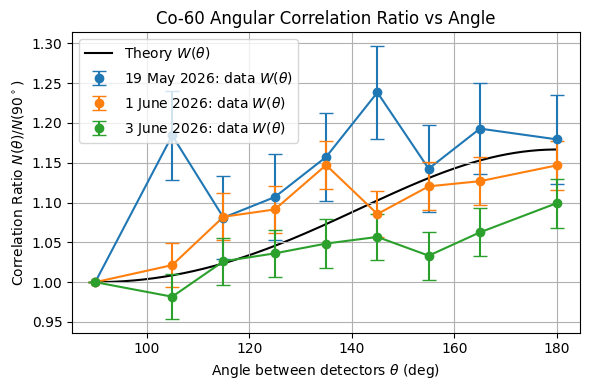

In [33]:
norm_angle = 90.0

angles = coinc_df_19May2026.index.to_numpy(dtype=float)
fine_angles = np.linspace(angles[0], angles[-1], 10**3)

corr_ratio_19May2026 = coinc_df_19May2026["W"].to_numpy(dtype=float)
corr_ratio_unc_19May2026 = coinc_df_19May2026["W_unc"].to_numpy(dtype=float)

corr_ratio_1June2026 = coinc_df_1June2026["W"].to_numpy(dtype=float)
corr_ratio_unc_1June2026 = coinc_df_1June2026["W_unc"].to_numpy(dtype=float)

corr_ratio_3June2026 = coinc_df_3June2026["W"].to_numpy(dtype=float)
corr_ratio_unc_3June2026 = coinc_df_3June2026["W_unc"].to_numpy(dtype=float)


fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    angles, corr_ratio_19May2026, yerr=corr_ratio_unc_19May2026,
    capsize=5, fmt="o", color="C0", label=r"19 May 2026: data $W(\theta)$",
)

ax.plot(
    angles, corr_ratio_19May2026, color="C0"
)

ax.errorbar(
    angles, corr_ratio_1June2026, yerr=corr_ratio_unc_1June2026,
    capsize=5, fmt="o", color="C1", label=r"1 June 2026: data $W(\theta)$",
)

ax.plot(
    angles, corr_ratio_1June2026, color="C1"
)


ax.errorbar(
    angles, corr_ratio_3June2026, yerr=corr_ratio_unc_1June2026,
    capsize=5, fmt="o", color="C2", label=r"3 June 2026: data $W(\theta)$",
)

ax.plot(
    angles, corr_ratio_3June2026, color="C2"
)


ax.plot(
    fine_angles, co60_angular_correlation(fine_angles),
    label=r"Theory $W(\theta)$",
    color='black',
    zorder=1
)

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Correlation Ratio $N(\theta)/N(90^\circ)$")
ax.set_title("Co-60 Angular Correlation Ratio vs Angle")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

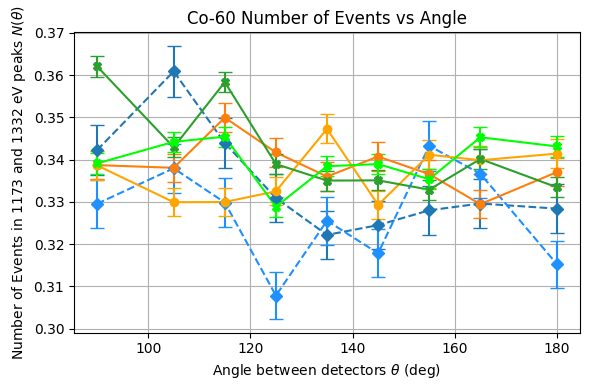

In [50]:
angles = coinc_df_19May2026.index.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ch1_n_19May2026 = ch1_trig_df_19May2026["N_norm"].to_numpy(dtype=float)
ch1_n_unc_19May2026 = ch1_trig_df_19May2026["N_unc_norm"].to_numpy(dtype=float)

ch2_n_19May2026 = ch2_trig_df_19May2026["N_norm"].to_numpy(dtype=float)
ch2_n_unc_19May2026 = ch2_trig_df_19May2026["N_unc_norm"].to_numpy(dtype=float)

ch1_n_1June2026 = ch1_trig_df_1June2026["N_norm"].to_numpy(dtype=float)
ch1_n_unc_1June2026 = ch1_trig_df_1June2026["N_unc_norm"].to_numpy(dtype=float)

ch2_n_1June2026 = ch2_trig_df_1June2026["N_norm"].to_numpy(dtype=float)
ch2_n_unc_1June2026 = ch2_trig_df_1June2026["N_unc_norm"].to_numpy(dtype=float)


ch1_n_3June2026 = ch1_trig_df_3June2026["N_norm"].to_numpy(dtype=float)
ch1_n_unc_3June2026 = ch1_trig_df_3June2026["N_unc_norm"].to_numpy(dtype=float)

ch2_n_3June2026 = ch2_trig_df_3June2026["N_norm"].to_numpy(dtype=float)
ch2_n_unc_3June2026 = ch2_trig_df_3June2026["N_unc_norm"].to_numpy(dtype=float)

ax.errorbar(
    angles, ch1_n_19May2026, yerr=ch1_n_unc_19May2026,
    capsize=5, fmt="D", color="C0", label=r"19 May 2026: Channel 1 $N(\theta)$",
)
ax.plot(angles, ch1_n_19May2026, color="C0", linestyle="--")

ax.errorbar(
    angles, ch2_n_19May2026, yerr=ch2_n_unc_19May2026,
    capsize=5, fmt="D", color="dodgerblue", label=r"19 May 2026: Channel 2 $N(\theta)$",
)
ax.plot(angles, ch2_n_19May2026, color="dodgerblue", linestyle="--")

ax.errorbar(
    angles, ch1_n_1June2026, yerr=ch1_n_unc_1June2026,
    capsize=5, fmt="o", color="C1", label=r"1 June 2026: Channel 1 $N(\theta)$",
)
ax.plot(angles, ch1_n_1June2026, color="C1")

ax.errorbar(
    angles, ch2_n_1June2026, yerr=ch2_n_unc_1June2026,
    capsize=5, fmt="o", color="orange", label=r"1 June 2026: Channel 2 $N(\theta)$",
)
ax.plot(angles, ch2_n_1June2026, color="orange")



ax.errorbar(
    angles, ch1_n_3June2026, yerr=ch1_n_unc_3June2026,
    capsize=5, fmt="X", color="C2", label=r"3 June 2026: Channel 1 $N(\theta)$",
)
ax.plot(angles, ch1_n_3June2026, color="C2")

ax.errorbar(
    angles, ch2_n_3June2026, yerr=ch2_n_unc_3June2026,
    capsize=5, fmt="X", color="lime", label=r"3 June 2026: Channel 2 $N(\theta)$",
)
ax.plot(angles, ch2_n_3June2026, color="lime")




ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Number of Events in 1173 and 1332 eV peaks $N(\theta)$")
ax.set_title("Co-60 Number of Events vs Angle")
ax.grid(True)
# ax.legend(framealpha=1)
fig.tight_layout()
plt.show()

In [27]:
""

''